In [1]:
import pandas as pd
import tempfile
from tokenizers import BertWordPieceTokenizer
from transformers import BertTokenizerFast
from transformers import BertConfig
from transformers import BertForMaskedLM
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments
from transformers import BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
from datasets import load_dataset
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import torch
import tqdm
from sklearn import model_selection
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
from torch import nn


In [2]:
comments = pd.read_csv('/kaggle/input/datasets/mcchainiy/comments-labels/comments.csv')

Обучаем токенайзер

In [ ]:
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
    for comment in comments['comment']:
        f.write(comment + '\n')
    temp_path = f.name

In [ ]:
tokenizer = BertWordPieceTokenizer(lowercase=True)

tokenizer.train(
    files=[temp_path],
    vocab_size=30000,
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)

In [ ]:
tokenizer.save_model("tokenizer")

In [ ]:
tokenizer.save("tokenizer/tokenizer.json")

Загружаем токенизатор

In [13]:
tokenizer = BertTokenizerFast.from_pretrained("./tokenizer")

Обучаем берт

In [ ]:
config = BertConfig(
    vocab_size=30000,
    hidden_size=256,
    num_hidden_layers=4,
    num_attention_heads=4,
    intermediate_size=512,
    max_position_embeddings=512
)

In [ ]:
model = BertForMaskedLM(config=config)

Dataset for mlm

In [ ]:
dataset = load_dataset(
    "text",
    data_files={"train": temp_path}
)

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

Маскируем датасет

In [ ]:

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

Обучаем модель

In [ ]:
training_args = TrainingArguments(
    output_dir="./custom_bert",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    learning_rate=5e-4,
    save_steps=1000,
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    data_collator=data_collator
)

trainer.train()

In [ ]:
trainer.save_model("./bert")
tokenizer.save_pretrained("./bert")

Готовимся к классификации

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "./bert",
    num_labels=4
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
# comments = pd.read_csv("/Users/danil/Desktop/toxic-comments/data/comments.csv")
comments = pd.read_csv("/kaggle/input/datasets/mcchainiy/comments-labels/comments.csv")

In [3]:
le = LabelEncoder()
comments['label'] = le.fit_transform(comments['label'])

In [4]:
!ls

In [5]:
# comments.to_csv('../../data/comments_labels_num.csv', index=False)
comments.to_csv('comments_labels_num.csv', index=False)

In [8]:
# dataset = load_dataset("csv", data_files="/Users/danil/Desktop/toxic-comments/data/comments_labels_num.csv")
dataset = load_dataset("csv", data_files="comments_labels_num.csv")
dataset = dataset.class_encode_column("label")

Generating train split: 0 examples [00:00, ? examples/s]

Stringifying the column:   0%|          | 0/248281 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/248281 [00:00<?, ? examples/s]

In [9]:
dataset = dataset["train"].train_test_split(test_size=0.2, stratify_by_column='label')

In [11]:
# это для kaggle (тут все запутано и я беру токенайзер из хронологически еще не обученной модели но так надо, чтобы задать train_dataset и val_dataset)
model_path = '/kaggle/input/models/mcchainiy/bert-clf/transformers/default/1/bert-clf'
tokenizer = BertTokenizerFast.from_pretrained(model_path)

In [12]:
def tokenize_classification(examples):
    return tokenizer(
        examples["comment"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize_classification, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/198624 [00:00<?, ? examples/s]

Map:   0%|          | 0/49657 [00:00<?, ? examples/s]

In [33]:
train_dataset = dataset["train"]
val_dataset = dataset["test"]

Обучаем классификацию

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    preds = np.argmax(logits, axis=1)
    
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds)
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    logging_steps=100
    )

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
100,0.904800
200,0.619400
300,0.615900
400,0.625600
500,0.634200
600,0.586100
700,0.606300
800,0.589700
900,0.583100
1000,0.554400


/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=37242, training_loss=0.25205809781569416, metrics={'train_runtime': 3310.4215, 'train_samples_per_second': 179.999, 'train_steps_per_second': 11.25, 'total_flos': 995686895812608.0, 'train_loss': 0.25205809781569416, 'epoch': 3.0})

In [40]:
trainer.save_model("bert-clf")
tokenizer.save_pretrained("bert-clf")

('bert-clf/tokenizer_config.json',
 'bert-clf/special_tokens_map.json',
 'bert-clf/vocab.txt',
 'bert-clf/added_tokens.json',
 'bert-clf/tokenizer.json')

Загружаем обученную модель

In [19]:
model_path = "bert-clf"
# model_path = '/kaggle/input/models/mcchaniy/bert-clf/transformers/default/1/bert-clf'


tokenizer = BertTokenizerFast.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

In [20]:
label_map = {
    0: "INSULT",
    1: "NORMAL",
    2: "OBSCENITY",
    3: "THREAT"
}

In [21]:
def bert_predict_series(texts, batch_size=32):
    model.eval()
    
    all_preds = []
    
    texts = texts.tolist()
    
    for i in tqdm.tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
    
    return [label_map[p] for p in all_preds]

Используем модель

In [93]:
df = pd.read_csv('../../data/comments.csv')
X = df['comment']
y = df['label']

# X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, 
#                                                                     random_state=42, stratify=y)

In [ ]:
def print_multiclass_metrics(y_test, y_pred, model_name='LR'):
    print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
    print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
    print(f"{model_name} accurcay:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['INSULT', 'NORMAL', 'THREAT', 'OBSCENITY']))


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=df['label'].unique(), yticklabels=df['label'].unique())

In [22]:
y_pred = bert_predict_series(X)

100%|██████████| 7759/7759 [06:53<00:00, 18.75it/s]


f1 macro score: 0.8184413090932952
f1 weighted score: 0.9562655531031625
LR accurcay: 0.9574474083800211
              precision    recall  f1-score   support

      INSULT       0.84      0.86      0.85     28566
      NORMAL       0.98      0.99      0.99    203677
      THREAT       0.77      0.51      0.62      4261
   OBSCENITY       0.86      0.78      0.82     11777

    accuracy                           0.96    248281
   macro avg       0.86      0.79      0.82    248281
weighted avg       0.96      0.96      0.96    248281



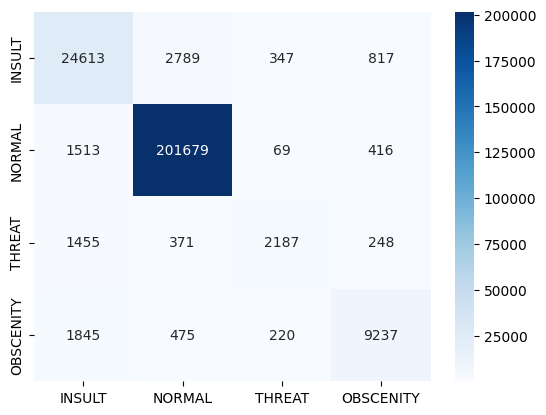

In [23]:
print_multiclass_metrics(y, y_pred)

Предыдущий результат не устроил, дообучаем берт (с выводом метрик)

In [31]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1_macro = f1_score(labels, predictions, average='macro')
    
    return {
        'f1_macro': f1_macro
    }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        weights = torch.tensor([4.0, 1.0, 20.0, 8.0], device=logits.device) 
        
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [34]:
training_args = TrainingArguments(
    output_dir="./bert_output2",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    save_total_limit=3,
    learning_rate=5e-5,
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,F1 Macro
500,0.414201,0.362479,0.799089
1000,0.420495,0.359496,0.811868
1500,0.368876,0.312656,0.822778
2000,0.298247,0.307957,0.843658
2500,0.334013,0.291568,0.842355
3000,0.299947,0.278546,0.836583
3500,0.250193,0.300437,0.858361
4000,0.268023,0.290339,0.839594
4500,0.235620,0.279932,0.865306
5000,0.250807,0.286959,0.872323


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

TrainOutput(global_step=31040, training_loss=0.1442050031395917, metrics={'train_runtime': 2142.8326, 'train_samples_per_second': 926.923, 'train_steps_per_second': 14.485, 'total_flos': 3318956319375360.0, 'train_loss': 0.1442050031395917, 'epoch': 10.0})

In [35]:
trainer.save_model("bert-clf2")
tokenizer.save_pretrained("bert-clf2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert-clf2/tokenizer_config.json', 'bert-clf2/tokenizer.json')

In [36]:
import shutil
shutil.make_archive('bert-clf2', 'zip', './bert-clf2')

'/kaggle/working/bert-clf2.zip'

In [38]:
shutil.make_archive('bert-clf2-checkpoint8000', 'zip', 'bert_output2/checkpoint-8000')

'/kaggle/working/bert-clf2-checkpoint8000.zip'

Проверим новую модель

In [2]:
model_path = "bert-clf2"
# model_path = '/kaggle/input/models/mcchainiy/bert-clf/transformers/default/1/bert-clf'


tokenizer = BertTokenizerFast.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

In [3]:
label_map = {
    0: "INSULT",
    1: "NORMAL",
    2: "THREAT",
    3: "OBSCENITY"
}
def bert_predict_series(texts, batch_size=32):
    model.eval()
    
    all_preds = []
    
    texts = texts.tolist()
    
    for i in tqdm.tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
    
    return [label_map[p] for p in all_preds]

In [ ]:
df = pd.read_csv('../../data/comments.csv')
X = df['comment']
y = df['label']
y_pred = bert_predict_series(X)

100%|██████████| 7759/7759 [06:52<00:00, 18.79it/s]


In [11]:
def print_multiclass_metrics(y_test, y_pred, model_name='LR'):
    print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
    print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
    print(f"{model_name} accurcay:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['INSULT', 'NORMAL', 'THREAT', 'OBSCENITY']))


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=df['label'].unique(), yticklabels=df['label'].unique())

f1 macro score: 0.4791616306429526
f1 weighted score: 0.9170565079518297
LR accurcay: 0.9144920473173541
              precision    recall  f1-score   support

      INSULT       0.89      0.93      0.91     28566
      NORMAL       1.00      0.98      0.99    203677
      THREAT       0.01      0.02      0.01      4261
   OBSCENITY       0.01      0.00      0.01     11777

    accuracy                           0.91    248281
   macro avg       0.48      0.48      0.48    248281
weighted avg       0.92      0.91      0.92    248281



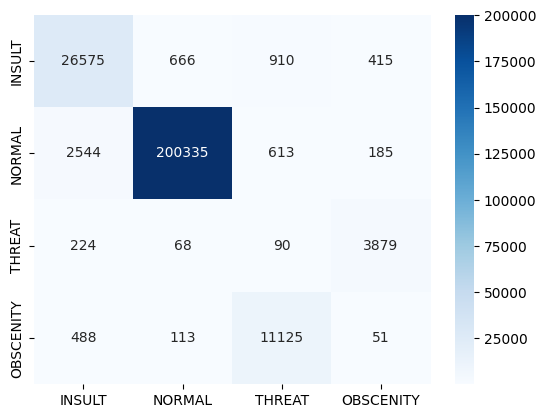

In [12]:
print_multiclass_metrics(y, y_pred)

In [17]:
y_pred_changed = pd.Series(y_pred).replace({
    'OBSCENITY': 'THREAT',
    'THREAT': 'OBSCENITY'
})

f1 macro score: 0.9224759320730029
f1 weighted score: 0.9747750411068578
LR accurcay: 0.97435566958406
              precision    recall  f1-score   support

      INSULT       0.89      0.93      0.91     28566
      NORMAL       1.00      0.98      0.99    203677
      THREAT       0.86      0.91      0.88      4261
   OBSCENITY       0.87      0.94      0.91     11777

    accuracy                           0.97    248281
   macro avg       0.90      0.94      0.92    248281
weighted avg       0.98      0.97      0.97    248281



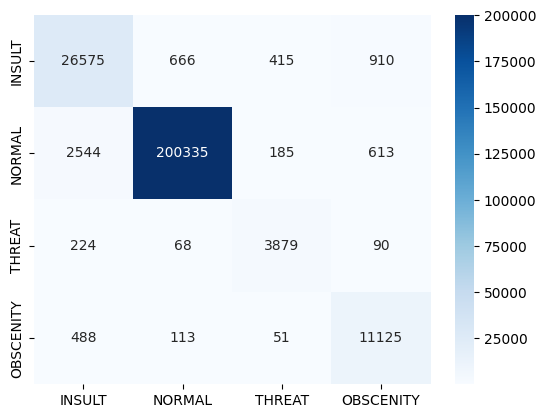

In [18]:
print_multiclass_metrics(y, y_pred_changed)